In [1]:
!pip install transformers torch torchvision pillow

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import os

In [3]:
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

c:\Users\Lenovo\Internship\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [4]:
dataset_path = r"C:\Users\Lenovo\Internship\data\Flickr8k"

image_folder = os.path.join(dataset_path, "images")

In [5]:
import random

sample_images = random.sample(os.listdir(image_folder), 5)

c:\Users\Lenovo\Internship\venv\Lib\site-packages\transformers\generation\utils.py:1625: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


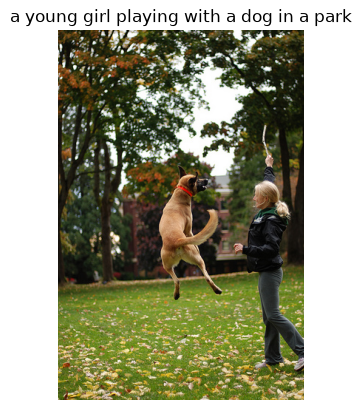

Image: 2960033435_c20cc7399a.jpg
Generated Caption: a young girl playing with a dog in a park
------------------------------------------------------------


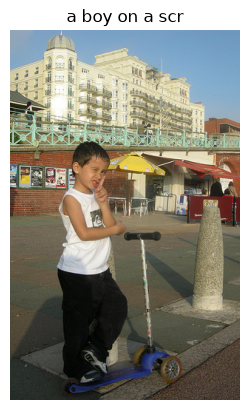

Image: 2931950813_93145c4746.jpg
Generated Caption: a boy on a scr
------------------------------------------------------------


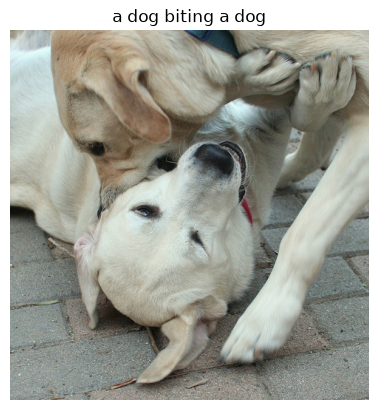

Image: 1470061031_4cb59c12a8.jpg
Generated Caption: a dog biting a dog
------------------------------------------------------------


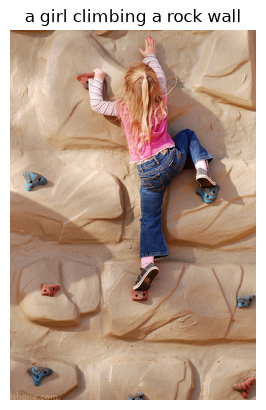

Image: 2304444199_05386d2e9c.jpg
Generated Caption: a girl climbing a rock wall
------------------------------------------------------------


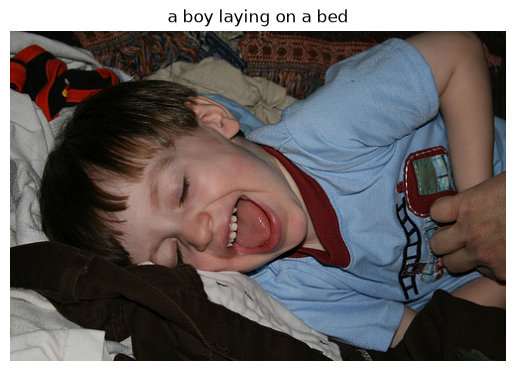

Image: 1721637099_93e9ec2a2f.jpg
Generated Caption: a boy laying on a bed
------------------------------------------------------------


In [6]:
for image_name in sample_images:

    image_path = os.path.join(image_folder, image_name)

    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    output = model.generate(**inputs)

    caption = processor.decode(output[0], skip_special_tokens=True)

    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)
    plt.show()

    print("Image:", image_name)
    print("Generated Caption:", caption)
    print("-"*60)